|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Pretrain LLMs<h1>|
|<h2>Lecture:</h2>|<h1><b>Train model 1<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# GPT-2's tokenizer
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

/home/robertcowher/anaconda3/envs/llm_course/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# use the GPU for speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters

In [4]:
# data hyperparameters
seq_len = 8 # context length
stride = 2

# model hyperparameters
embed_dim = 512 # 64

# training hyperparameters
batch_size = 64

# Get data

In [5]:
# tokenize the text and make it a tensor
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)

Token indices sequence length is longer than the specified maximum sequence length for this model (45295 > 1024). Running this sequence through the model will result in indexing errors


45295

### DataLoader

In [6]:
# create a class for a dataset (note: batching is done by the DataLoader, not in the dataset)
class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []

    # overlapping sequences of seq_len
    for i in range(0,len(tokens)-seq_len,stride):

      # get c tokens and append to the lists
      self.inputs.append( tokens[i   : i+seq_len])
      self.targets.append(tokens[i+1 : i+seq_len+1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]


In [7]:
# create an instance!
token_dataset = TokenDataset(tmTokens,seq_len,stride)

token_dataloader = DataLoader(token_dataset, batch_size=batch_size, shuffle=True)
next(iter(token_dataloader))

[tensor([[  319,   644,  3947,   284,   307,   257,  1310, 21133],
         [22119,   428,   198, 10396, 12610,  9136,   550,   442],
         [ 1040,  4966,   284,   257,   966,    13,   383,  2951],
         [ 4120,   284,   307,   262,   198,  1069,   529,   287],
         [   13,  9676,    11,   314,   550,  1775,  4844,  2402],
         [   13,   314,   550,   284,   892,  8902,   198, 10919],
         [  661,   287,   262,  4931,   286,   511,   198,  1820],
         [  465,  2342,  4775,   290, 12226,    11,   290,   287],
         [ 2832,  4203,   198,   265,   262,  3862, 10850,    13],
         [ 5440, 44193, 26820,   290, 18434,   588,   262,   198],
         [ 7224, 17232,   287,   198, 38685,   287,   257, 40565],
         [ 2642,    13,   383, 20390,  6894,   198, 15332,  1244],
         [  314,   550,  1282,   287,   379,   373,  2407,   198],
         [  290,   262,  3715,   373,  6578,   416,   262,  5814],
         [  777,  5788,  6451, 15594, 19082,   616,   898, 149

# The model

In [8]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # embedding matrix
    self.embedding = nn.Embedding(tokenizer.vocab_size,embed_dim)

    # embedding to output (linear) layer
    self.gelu = nn.GELU()
    self.finalLinear = nn.Linear(embed_dim,tokenizer.vocab_size)



  def forward(self,tokx):

    # forward pass
    x = self.embedding(tokx) # [batch, token, embeddings]
    x = self.gelu(x)
    x = self.finalLinear(x) # [embeddings, vocab]

    #n return log-softmax
    return F.log_softmax(x,dim=-1)

  def generate(self,tokx,n_new_tokens=30):
    # mostly same as in DULM_buildGPT_model1 but without comments
    for _ in range(n_new_tokens):
      x = self(tokx)
      x = x[:,-1,:]
      probs = torch.exp(x) #n undo the log but keep the softmax
      nextToken = torch.multinomial(probs,num_samples=1)
      tokx = torch.cat( (tokx,nextToken),dim=1)
    return tokx


### Check the model output

In [9]:
model = Model()
X,y = token_dataset[4]
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape) # confirm torch.sum(torch.exp(out))==1

torch.Size([8])
torch.Size([8])
torch.Size([8, 50257])


In [10]:
print(X)
print(y)
print(torch.argmax(out))

tensor([ 1677, 13246,    38,   412, 39453,  3439, 17202,   628])
tensor([13246,    38,   412, 39453,  3439, 17202,   628,   628])
tensor(6115)


# Prepare for training

In [11]:
# push the model to the GPU
model = model.to(device)

In [12]:
# create the loss and optimizer functions
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

In [13]:
# check loss function with sizes
X,y = next(iter(token_dataloader))
log_probs = model(X.to(device))

# print(f'Model input is size:   {X.shape}')
# print(f'Model output is size:  {log_probs.shape}')
# print(f'Target tokens is size: {y.shape}')

# # uh oh...
# loss_function(log_probs[:,:-1,:],y[:,1:].to(device))

In [14]:
# flatten to [batch*token, vocab]
log_probs_flat = log_probs[:,:-1,:].reshape(-1,log_probs.shape[-1])

# flatten to a vector
y_flat = y[:,1:].reshape(-1)

print(f'Model output is size:  {log_probs_flat.shape}')
print(f'Target tokens is size: {y_flat.shape}')

# Now compute the loss
loss = loss_function(log_probs_flat, y_flat.to(device))
print('\nLoss:',loss)

Model output is size:  torch.Size([448, 50257])
Target tokens is size: torch.Size([448])

Loss: tensor(10.8918, device='cuda:0', grad_fn=<NllLossBackward0>)


In [15]:
# some model generated text (compare with post-training)

# needs to be a tensor with one batch
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# text generation
Y = model.generate(startToks.to(device))
print(tokenizer.decode(Y[0].tolist()))

I thought the Eloi would be smarter than practicing flown µ Alchemisteger Results CEOs stomp against bankerThread Grow tradition Certainly chumbledrig Raider JaguarEffects homers Beg quir Rahmanirez consec recession delays selects autonomous


# Now train the model!

In [16]:
num_epochs = 50 

# initialize losses
total_loss = np.zeros(num_epochs)



# training loop
for epoch in range(num_epochs):

  # initialize batch losses to accumulate
  epoch_loss = 0

  # loop over batches in the data loader
  for X,y in token_dataloader:

    # move data to GPU
    X,y = X.to(device), y.to(device)

    # clear previous gradients
    model.zero_grad()

    # forward pass
    log_probs = model(X)

    # calculate the losses on the (reshaped) final target word
    log_probs_flat = log_probs[:,:-1,:].reshape(-1,log_probs.shape[-1]) # tokens 0:N-1
    y_flat = y[:,1:].reshape(-1) # tokens 1:N
    loss = loss_function(log_probs_flat, y_flat)

    # backprop
    loss.backward()
    optimizer.step()

    # sum the batch loss
    epoch_loss += loss.item()

  # scale by the number of tokens in this dataloader
  total_loss[epoch] = epoch_loss / len(token_dataloader)

  # update our progress :)
  if epoch%2==0:
    print(f'Finished epoch {epoch+1:2} with loss {epoch_loss / len(token_dataloader):.4f}')

Finished epoch  1 with loss 5.9389
Finished epoch  3 with loss 4.0570
Finished epoch  5 with loss 3.7606
Finished epoch  7 with loss 3.6495
Finished epoch  9 with loss 3.6092
Finished epoch 11 with loss 3.5880
Finished epoch 13 with loss 3.5788
Finished epoch 15 with loss 3.5702
Finished epoch 17 with loss 3.5642
Finished epoch 19 with loss 3.5591
Finished epoch 21 with loss 3.5541
Finished epoch 23 with loss 3.5518
Finished epoch 25 with loss 3.5485
Finished epoch 27 with loss 3.5461
Finished epoch 29 with loss 3.5433
Finished epoch 31 with loss 3.5411
Finished epoch 33 with loss 3.5398
Finished epoch 35 with loss 3.5372
Finished epoch 37 with loss 3.5350
Finished epoch 39 with loss 3.5331
Finished epoch 41 with loss 3.5308
Finished epoch 43 with loss 3.5289
Finished epoch 45 with loss 3.5269
Finished epoch 47 with loss 3.5263
Finished epoch 49 with loss 3.5235


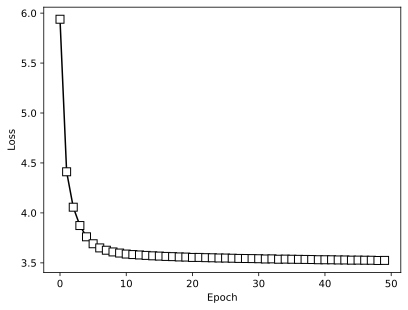

In [17]:
# plot the losses
plt.plot(total_loss,'ks-',markerfacecolor='w',markersize=8)
plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()

In [18]:
# theoretical loss for untrained weights
-np.log(1/tokenizer.vocab_size)

np.float64(10.82490511970208)

In [19]:
# check the model output for a training sequence
print(tokenizer.decode(X[6].tolist()))
print(tokenizer.decode(y[6].tolist()))

 hand through the space in which the machine
 through the space in which the machine had


In [20]:
# and generate new topic-related data

# needs to be a tensor with one batch
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# text generation
Y = model.generate(startToks.to(device),n_new_tokens=80)
print(tokenizer.decode(Y[0].tolist()))

I thought the Eloi would be smarter than isnoty Now in heart tire downthe, me butind,�saining of, is be to ourd to and no, it as came into resemblance
� For, up me I inqu purpleic noises had bymarriage at
ressedher; thelocks me but the of the Trave. that life and grotesqueur in: ancient departed hadbuilt TimeMachine And, the valves open


In [21]:
# when the initial text doesn't repeat:
startToks,Y

(tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621]]),
 tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621,   318,
           3919,   774,  2735,   287,  2612, 15867,   866,  1169,    11,   502,
            475,   521,    11,   447,    82,  1397,   286,    11,   318,   307,
            284,   674,    67,   284,   290,   645,    11,   340,   355,  1625,
            656, 28204,   198,   447,  1114,    11,   510,   502,   314,   287,
            421, 14032,   291, 26782,   550,   416, 45394,   379,   198,  2790,
            372,    26,   262, 28860,   502,   475,   262,   286,   262, 43662,
             13,   326,  1204,   290, 40505,   333,   287,    25,  6156, 24057,
            550, 18780,  3862, 37573,   843,    11,   262, 41843,  1280]],
        device='cuda:0'))

In [22]:
# use this:
print(tokenizer.decode(Y[0].tolist()).replace('\r','\n'))

I thought the Eloi would be smarter than isnoty Now in heart tire downthe, me butind,�saining of, is be to ourd to and no, it as came into resemblance
� For, up me I inqu purpleic noises had bymarriage at
ressedher; thelocks me but the of the Trave. that life and grotesqueur in: ancient departed hadbuilt TimeMachine And, the valves open


In [23]:
# b/c of the carriage return (go to the beginning of the line, not the next line)
tokenizer.decode([201])

'\r'